# Výpočet tepové frekvence z EKG signálu

## Zadání
Ve zdrojové databázi najdete celkem 17 měření EKG signálu. Signál je již filtrován a centralizován kolem podélné osy. EKG signál obsahuje dominantní peaky, které se nazývají R vrcholy. Vzdálenost těchto vrcholů určuje dobu mezi jednotlivými tepy. Počet tepů za minutu je tedy počet R vrcholů v signálu o délce jedné minuty. Navrhněte algoritmus, který bude automaticky detekovat počet R vrcholů v EKG signálech a prezentujte tepovou frekvenci při jednotlivých jízdách/měřeních. Vás algoritmus následně otestujte na databázi MIT-BIH https://physionet.org/content/nsrdb/1.0.0/ a prezentujte jeho úspěšnost vzhledem k anotovaným datům z databáze.

## Postup řešení

In [31]:
import wfdb
import matplotlib.pyplot as plt
import scipy.signal
import numpy as np
import copy
import os
import seaborn as sns

In [32]:
sampfrom = 1300
#samp, rinfo = wfdb.rdsamp("data/drive12", channels=[0], sampfrom=sampfrom, sampto=sampfrom+100)
samp, rinfo = wfdb.rdsamp("data/drive12", channels=None, sampfrom=sampfrom, sampto=sampfrom+100)
samp = samp.flatten()
rinfo

{'fs': 15.5,
 'sig_len': 100,
 'n_sig': 7,
 'base_date': None,
 'base_time': None,
 'units': ['mV', 'mV', 'mV', 'mV', 'bpm', 'mV', 'mV'],
 'sig_name': ['ECG', 'EMG', 'foot GSR', 'hand GSR', 'HR', 'marker', 'RESP'],
 'comments': []}

In [33]:
# Funkce pro načtení dat ze souboru
def nacti_data(soubor, kanaly=[0], sampfrom=0, sampto=1000):
    vzorky, informace = wfdb.rdsamp(soubor, channels=kanaly, sampfrom=sampfrom, sampto=sampto)
    vzorky = vzorky.flatten()
    vzorkovaci_frekvence = informace["fs"]
    return vzorkovaci_frekvence, vzorky

# Funkce pro načtení dat z jednotlivých jízd
def nacti_jizdu(cislo_jizdy, kanaly=[0], sampfrom=0, sampto=1000):
    nazev = "drive%s" % str(cislo_jizdy).zfill(2)
    cesta_k_souboru = os.path.join("data", nazev)
    return nacti_data(cesta_k_souboru, kanaly=kanaly, sampfrom=sampfrom, sampto=sampto)

# Funkce pro detekci vrcholů v signálu
def detekuj_vrcholy(X, N=5, oblast=3, r_prah=50, p_prah=90, vykresli=False):
    # Krátkodobá Fourierova transformace
    WS = (N//2)+1 # velikost okna
    f, t, Zxx = scipy.signal.stft(X, nperseg=N, noverlap=0)
    Zxx = np.abs(Zxx).reshape(-1, WS)

    # Detekce oblastí zájmu (RoI - Regions of Interest)
    max_v_okne = np.max(Zxx, axis=1)
    prahovy_filtr = np.percentile(max_v_okne, r_prah) # Ntý percentil
    intervaly = t[max_v_okne > prahovy_filtr]

    # Detekce peaků
    prahovy_pik = np.percentile(X, p_prah)
    piku = []
    for zaklad in intervaly.astype(int):
        if zaklad >= X.size:
            continue
        if zaklad > WS+oblast:
            zaklad = zaklad-WS-oblast
        konec = zaklad + N + oblast*2
        okno = X[zaklad:konec]
        max_v_okne = np.max(okno)
        if max_v_okne > prahovy_pik:
            cas_piku = zaklad + np.argmax(okno)
            if cas_piku in piku:
                continue
            piku.append(cas_piku)

    # Vykreslení oblastí zájmu a peaků
    if vykresli:
        xmin = np.min(X)
        xmax = np.max(X)
        plt.plot(X, linewidth=5, label="EKG")
        plt.vlines(intervaly-WS-oblast, ymin=xmin, ymax=xmax, color="g", linewidth=0.5, label="začátek RoI")
        plt.vlines(intervaly+N+oblast*2, ymin=xmin, ymax=xmax, color="b", linewidth=0.5, label="konec RoI")
        plt.vlines(piku, ymin=xmin, ymax=xmax, color="r", label="peak")
        plt.legend()

    return piku

# Funkce pro oříznutí signálu do vrcholu R
def orez_do_vrcholu(X, vzorkovaci_frekvence, chyba=True):
    vzorkovaci_frekvence = int(vzorkovaci_frekvence)
    piku = detekuj_vrcholy(X[:vzorkovaci_frekvence*2])
    if not piku and not chyba:
        # Pokud není detekován vrchol R, ořízneme do max hodnoty v intervalu sr*2
        print("Vrchol R nebyl detekován -> ořezání do max hodnoty v intervalu sr*2")
        index_max = np.argmax(X[:vzorkovaci_frekvence*2])
        return X[index_max:]
    elif not piku and chyba:
        raise Exception("Vrchol nebyl detekován")
    vrchol = piku[0]
    return X[vrchol:]

# Funkce pro převzorkování signálu
def prevzorkuj(X, vzorkovaci_frekvence, cilova_vzorkovaci_frekvence, orez=False):
    pomer = cilova_vzorkovaci_frekvence / vzorkovaci_frekvence
    velikost_X = X.size
    pocet = int(velikost_X * pomer)
    prevzorkovane_X = scipy.signal.resample(X, pocet)
    if orez:
        return prevzorkovane_X[:velikost_X]
    return prevzorkovane_X

# Funkce pro párování signálů
def sparuj_signaly(signaly, vzorkovaci_frekvence):
    signaly = copy.deepcopy(signaly)

    # Převzorkování
    vzorkovaci_frekvence = vzorkovaci_frekvence[0]
    # Je potřeba převzorkování
    if np.min(vzorkovaci_frekvence) != np.max(vzorkovaci_frekvence):
        index_max_vzorkovaci_frekvence = np.argmax(vzorkovaci_frekvence)
        max_vzorkovaci_frekvence = vzorkovaci_frekvence[index_max_vzorkovaci_frekvence]
        vzorkovaci_frekvence = max_vzorkovaci_frekvence

        for i, (signal, vzorkovaci_frekvence) in enumerate(zip(signaly, vzorkovaci_frekvence)):
            print("Převzorkování %s" % i)
            if vzorkovaci_frekvence == max_vzorkovaci_frekvence:
                continue
            prevzorkovany_signal = prevzorkuj(signal, vzorkovaci_frekvence, max_vzorkovaci_frekvence, orez=True)
            signaly[i] = prevzorkovany_signal

    # Ořez na vrchol R
    for i, (signal, vzorkovaci_frekvence) in enumerate(zip(signaly, vzorkovaci_frekvence)):
        print("Ořez na vrchol %s" % i)
        signaly[i] = orez_do_vrcholu(signal, vzorkovaci_frekvence, chyba=False)

    # Změna velikosti
    velikosti = [s.size for s in signaly]
    velikost = velikosti[0]
    # Je potřeba změnit velikost
    if np.min(velikosti) != np.max(velikosti):
        index_min_velikosti = np.argmin(velikosti)
        min_velikost = velikosti[index_min_velikosti]
        velikost = min_velikost

        for i, (signal, velikost) in enumerate(zip(signaly, velikosti)):
            if velikost == min_velikost:
                continue
            print("Změna velikosti %s" % i)
            signaly[i] = signal[:min_velikost]

    return signaly, vzorkovaci_frekvence, velikost

# Funkce pro usměrnění signálu
def usmereni(s1):
    return np.abs(s1)

# Funkce pro integraci signálu
def integrace(s1, velikost_okna):
    return np.convolve(s1, np.ones(velikost_okna), mode="same")

# Funkce pro detekci změn
def detekuj_zmeny(s1, velikost_okna, prah=0.01, vykresli=False):
    ts1 = s1[:s1.size - s1.size%velikost_okna]

    zmeny = []
    for i, okno in enumerate(np.split(ts1, ts1.size / velikost_okna)):
        zaklad = i * velikost_okna
        konec = (i+1) * (velikost_okna) - 1

        gradient = np.gradient(okno)
        gradient = np.sum(gradient)

        if gradient > prah:
            zmeny.append( (zaklad, konec, True) )
        elif gradient < -prah:
            zmeny.append( (zaklad, konec, False) )

    if vykresli:
        plt.plot(ts1)
        for (zaklad, konec, roste) in zmeny:
            barva = "green" if roste else "red"
            plt.axvspan(zaklad, konec, color=barva, alpha=0.5)

    return zmeny


19
70.67999999999999


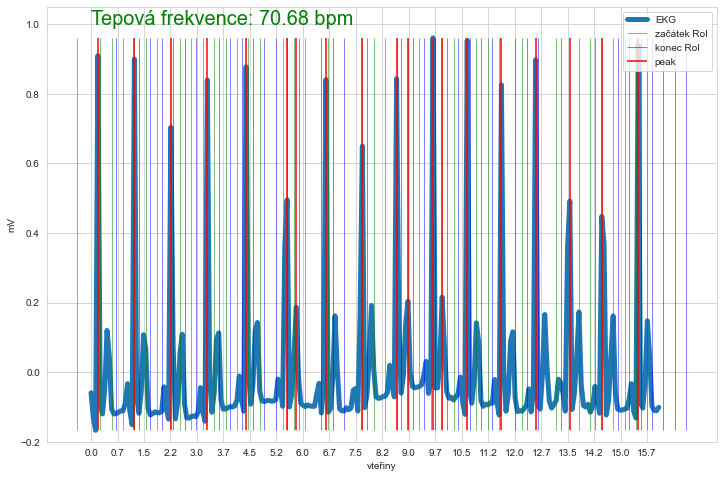

In [35]:
sr, signal = nacti_jizdu(12, sampfrom=0, sampto=250)
seconds = signal.size / sr
plt.figure(figsize=(12, 8))
peaks = detekuj_vrcholy(signal, N=5, r_prah=20, p_prah=90, vykresli=True)
npeaks = len(peaks)
print(npeaks)
pps = npeaks / seconds
hr = pps*60
print(hr)
plt.text(0, 1, "Tepová frekvence: %.2f bpm" % hr, fontdict={"size": 20, "color": "green"})
plt.ylim(-0.2, 1.05)
plt.legend(loc="upper right")
plt.ylabel("mV")
plt.xlabel("vteřiny")
plt.xticks(np.arange(0, len(signal), 60*3/sr), np.round(np.arange(0, len(signal), 60*3/sr) / sr, 1))
plt.show()

In [38]:
def test_peak_detection(file, sampfrom=0, nsamp=100000, correct_threshold=0.0001):
    samp, rinfo = wfdb.rdsamp(file, channels=None, sampfrom=sampfrom, sampto=sampfrom+nsamp)
    ann = wfdb.rdann(file, extension="atr", sampfrom=sampfrom, sampto=sampfrom+nsamp)
    samp = samp[:, 0]
    sr = rinfo["fs"]

    peaks = detekuj_vrcholy(samp, N=int(sr/3), oblast=int(sr/6), r_prah=20, p_prah=90)

    threshold = correct_threshold
    total = ann.sample.size
    correct = 0
    wrong = 0
    for peak in peaks:
        detected = False
        for true_peak in ann.sample:
            delta = (true_peak+1) / (peak+1)
            deltap = np.abs(1-delta)
            if deltap < threshold:
                detected = True
                break

        if detected:
            correct += 1
        else:
            wrong += 1

    #print(correct, total, correct / total)
    #print(wrong)

    return correct, wrong, total, len(peaks)
percentages = []

for file in os.listdir("test-data"):
    if not file.endswith(".dat"):
        continue

    file = os.path.join("test-data", file.replace(".dat", ""))
    correct, wrong, total, detected_total = test_peak_detection(file)
    percent = correct / total
    percentages.append(percent)

    msg = "%s: correct peaks: %.3f %% correct: %s wrong: %s correct total: %s detected total: %s" % (
        file, percent*100, correct, wrong, total, detected_total)
    print(msg)

print("Average correct: %.3f %%" % (np.average(percentages)*100))

test-data\16265: correct peaks: 72.058 % correct: 949 wrong: 178 correct total: 1317 detected total: 1127
test-data\16272: correct peaks: 68.305 % correct: 681 wrong: 504 correct total: 997 detected total: 1185
test-data\16273: correct peaks: 68.866 % correct: 856 wrong: 247 correct total: 1243 detected total: 1103
test-data\16420: correct peaks: 64.471 % correct: 744 wrong: 282 correct total: 1154 detected total: 1026
test-data\16483: correct peaks: 68.147 % correct: 798 wrong: 279 correct total: 1171 detected total: 1077
test-data\16539: correct peaks: 83.288 % correct: 912 wrong: 175 correct total: 1095 detected total: 1087
test-data\16773: correct peaks: 48.670 % correct: 677 wrong: 480 correct total: 1391 detected total: 1157
test-data\16786: correct peaks: 66.805 % correct: 644 wrong: 526 correct total: 964 detected total: 1170
test-data\16795: correct peaks: 59.207 % correct: 627 wrong: 581 correct total: 1059 detected total: 1208
test-data\17052: correct peaks: 64.758 % correct